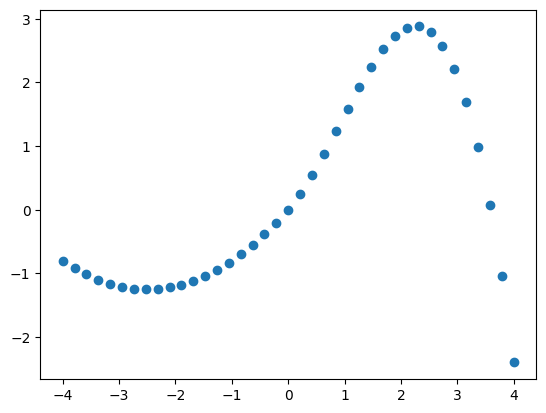

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import time

def quadratic(x, a=0.2, b=1, c=0):
    return a*x**2 + b*x + c

# Define the cubic function (for x > 0)
def cubic(x, d=-0.3, e=0.8, f=1, g=0):
    return d*x**3 + e*x**2 + f*x + g

quad=np.linspace(-4,0,20)
cube=np.linspace(0,4,20)

yquad=[quadratic(x) for x in quad]
ycube=[cubic(x) for x in cube]

xvals=np.concatenate((quad,cube[1:]))
yvals=np.concatenate((yquad,ycube[1:]))
zvals=np.zeros_like(xvals)

plt.plot(xvals,yvals,"o")


# #alternative x_vals,y_vals
# x=np.linspace(0,10,100)
# noisex = np.random.normal(loc=0, scale=0.25, size=x.shape)
# noisey= np.random.normal(loc=0, scale=0.25, size=x.shape)
# xvals=x+noisex
# yvals=x+noisey

xvalsalt=[quadratic(x) for x in np.linspace(5,10)]
yvalsalt=[cubic(x) for x in np.linspace(5,10)]


## SciPy CubicSpline

Total time taken: 0.0010077953338623047


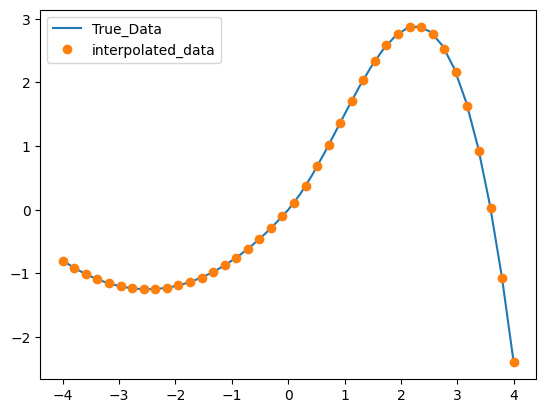

In [16]:
from scipy.interpolate import CubicSpline

s=time.time()
spline = CubicSpline(xvals, yvals)
print(spline)
x_spline = np.linspace(min(xvals), max(xvals), 40)
y_spline = spline(x_spline)

e=time.time()


plt.plot(xvals,yvals, label="True_Data")
plt.plot(x_spline,y_spline, 'o', label="interpolated_data")
plt.legend()
print(f"Total time taken: {e-s}")


## Bézier Least-squares fit 

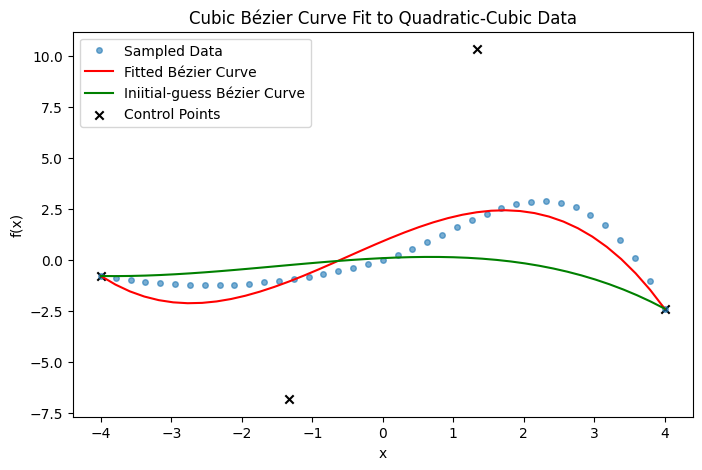

Total time taken: 0.018860340118408203


In [17]:
from scipy.optimize import least_squares


s=time.time()
# Parameterize t values (normalized between 0 and 1)
t_vals = np.linspace(0, 1, len(xvals))


def bezier_curve(t, P0, P1, P2, P3):
    return (1 - t) ** 3 * P0 + 3 * (1 - t) ** 2 * t * P1 + 3 * (1 - t) * t ** 2 * P2 + t ** 3 * P3

# Define residuals for least squares fitting
def bezier_residuals(control_pts, t_vals, x_data, y_data):
    P0, P3 = np.array([x_data[0], y_data[0]]), np.array([x_data[-1], y_data[-1]])
    P1, P2 = control_pts[:2], control_pts[2:]
    
    bezier_points = np.array([bezier_curve(t, P0, P1, P2, P3) for t in t_vals])
    return (bezier_points[:, 0] - x_data)**2 + (bezier_points[:, 1] - y_data)**2

# Initial guess for control points (midpoints for P1 and P2)
initial_guess = [xvals[len(xvals)//3], yvals[len(xvals)//3], 
                 xvals[2*len(xvals)//3], yvals[2*len(xvals)//3]]

# Optimize P1 and P2 using least squares
result_lm = least_squares(bezier_residuals, initial_guess, method="lm",args=(t_vals, xvals, yvals))
#result_trf = least_squares(bezier_residuals, initial_guess, method="trf",args=(t_vals, xvals, yvals))
#result_dog = least_squares(bezier_residuals, initial_guess, method="dogbox",args=(t_vals, xvals, yvals))
P1_opt_lm, P2_opt_lm = result_lm.x[:2], result_lm.x[2:]
#P1_opt_trf, P2_opt_trf = result_trf.x[:2], result_trf.x[2:]
#P1_opt_dog, P2_opt_dog = result_dog.x[:2], result_dog.x[2:]

P1_initial,P2_initial=np.array(initial_guess[:2]), np.array(initial_guess[2:])

# Compute Bézier curve points using optimized control points
P0, P3 = np.array([xvals[0], yvals[0]]), np.array([xvals[-1], yvals[-1]])
t_fine = np.linspace(0, 1, 40)
bezier_points_lm = np.array([bezier_curve(t, P0, P1_opt_lm, P2_opt_lm, P3) for t in t_fine])
#bezier_points_trf = np.array([bezier_curve(t, P0, P1_opt_trf, P2_opt_trf, P3) for t in t_fine])
#bezier_points_dog = np.array([bezier_curve(t, P0, P1_opt_dog, P2_opt_dog, P3) for t in t_fine])
bezier_points_initial=np.array([bezier_curve(t,P0, P1_initial, P2_initial, P3) for t in t_fine])
e=time.time()
# Plot original data and fitted Bézier curve
plt.figure(figsize=(8, 5))
plt.plot(xvals, yvals, 'o', label="Sampled Data", markersize=4, alpha=0.6)
plt.plot(bezier_points_lm[:, 0], bezier_points_lm[:, 1], label="Fitted Bézier Curve", color='r')
#plt.plot(bezier_points_trf[:, 0], bezier_points_trf[:, 1], label="Fitted Bézier Curve", )
#plt.plot(bezier_points_dog[:, 0], bezier_points_dog[:, 1], label="Fitted Bézier Curve", )
plt.plot(bezier_points_initial[:, 0], bezier_points_initial[:, 1], label="Iniitial-guess Bézier Curve", color='g')
plt.scatter([P0[0], P1_opt_lm[0], P2_opt_lm[0], P3[0]], 
            [P0[1], P1_opt_lm[1], P2_opt_lm[1], P3[1]], 
            color='black', marker='x', label="Control Points")
plt.legend()
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Cubic Bézier Curve Fit to Quadratic-Cubic Data")
plt.show()
print(f"Total time taken: {e-s}")

## Bézier CVX approx fit

Total time taken: 6440.47575712204
Total time taken: 6440.49941110611


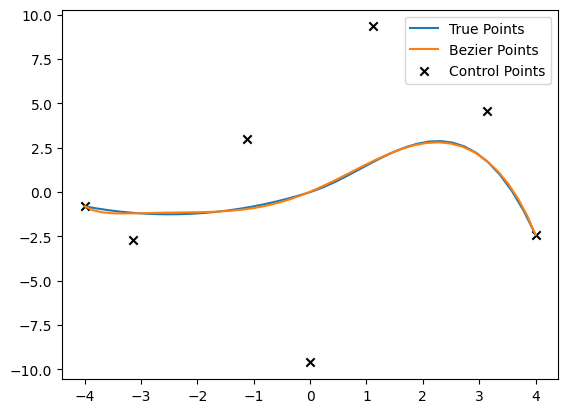

In [49]:
import cvxpy as cp
from math import comb
import math
import numpy as np


def bezier_curve2N(n, t, control_point_list):
    """
    Compute the Bézier curve at parameter t.
    
    Parameters:
    n (int): Degree of the Bézier curve.
    t (float): Parameter in range (0,1).
    control_points (np.ndarray): n x 2 array of control points.
    
    Returns:
    np.ndarray: (x, y) point on the Bézier curve.
    """
    if not (0 <= t <= 1):
        raise ValueError("t must be in the range (0,1)")
    
    if control_point_list.shape != (n + 1, 2):
        raise ValueError("control_points must be an (n+1) x 2 array")
    
    point = np.zeros(2)
    for i in range(n + 1):
        combinations=math.factorial(n)/(math.factorial(i)*math.factorial(n-i))
        #bernstein = comb(n, i) * (1 - t) ** (n - i) * t ** i
        bernstein = combinations * (1 - t) ** (n - i) * t ** i
        point += bernstein * control_point_list[i]
    
    return point
#t_range=np.linspace()

def control_points_2D(xvals,yvals):
    n=6
    Bpatch=np.zeros([n+1,n+1])
    for i in range(n+1):
        for j in range(n+1):
            Bpatch[i, j]=(-1)**(j-i)*comb(n,j)*comb(j,i)


    Pix=cp.Variable([n+1])
    Piy=cp.Variable([n+1])
    n_opt=8
    projection=[i/n_opt for i in range(n_opt+1)]
    cost=0

    control_points=np.zeros([n_opt+1,2])
    for i in range(n_opt+1):
        if i==n_opt:
            control_points[i]=[xvals[-1],yvals[-1]]
        else:
            control_points[i]=[xvals[i*len(xvals)//n_opt],yvals[i*len(xvals)//n_opt]]

    Kx=Bpatch.T@Pix
    Ky=Bpatch.T@Piy

    for i in range(n_opt+1):
        v=projection[i]
        V=np.array([v**k for k in range(n+1)])
        rsx=V@Kx
        rsy=V@Ky
        cost+=cp.square(cp.norm(cp.hstack([rsx-control_points[i][0], rsy-control_points[i][1]])))

    prob=cp.Problem(cp.Minimize(cost))
    prob.solve()

    Pi=np.dstack([Pix.value, Piy.value])[0]
    bezier_points = np.array([bezier_curve2N(n,t, Pi) for t in t_fine])
    e=time.time()
    print(f"Total time taken: {e-s}")
    return bezier_points, Pi

bezier_values, Pi=control_points_2D(xvals,yvals)
bezier_values1, Pi1=control_points_2D(xvalsalt,yvalsalt)
plt.plot(xvals,yvals, label="True Points")
plt.plot(bezier_values[:,0],bezier_values[:,1], label="Bezier Points")
plt.scatter([Pi[:,0]],[Pi[:,1]],color='black', marker='x', label="Control Points")
plt.legend()



## Bézier 3D curve fit

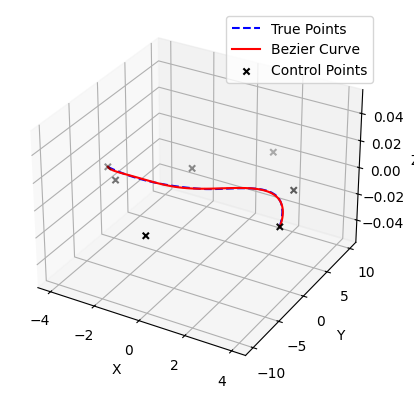

In [ ]:
import cvxpy as cp
from math import comb
import numpy as np
import matplotlib.pyplot as plt

def bezier_curve3N(n, t, control_points):

    if not (0 <= t <= 1):
        raise ValueError("t must be in the range (0,1)")

    if control_points.shape != (n + 1, 3):
        raise ValueError("control_points must be an (n+1) x 3 array")

    point = np.zeros(3)
    for i in range(n + 1):
        bernstein = comb(n, i) * (1 - t) ** (n - i) * t ** i
        point += bernstein * control_points[i]

    return point

# Generate sample data (Replace with your actual data)
t_vals = np.linspace(0, 1, 50)
#xvals = np.sin(2 * np.pi * t_vals)
#yvals = np.cos(2 * np.pi * t_vals)
#zvals = t_vals  # Example 3D trajectory
data_points = np.vstack([xvals, yvals, zvals]).T

# Define Bézier degree
n = 6

# Compute Bézier coefficient transformation matrix
Bpatch = np.zeros([n+1, n+1])
for i in range(n+1):
    for j in range(n+1):
        Bpatch[i, j] = (-1)**(j-i) * comb(n, j) * comb(j, i)

# Define optimization variables for 3D control points
Pix = cp.Variable(n+1)
Piy = cp.Variable(n+1)
Piz = cp.Variable(n+1)

n_opt = 10
projection = [i/n_opt for i in range(n_opt+1)]
cost = 0

# Initialize control points from sampled data
control_points = np.zeros([n_opt+1, 3])
for i in range(n_opt+1):
    if i == n_opt:
        control_points[i] = [xvals[-1], yvals[-1], zvals[-1]]
    else:
        idx = i * len(xvals) // n_opt
        control_points[i] = [xvals[idx], yvals[idx], zvals[idx]]

# Compute Bézier coefficients
Kx = Bpatch.T @ Pix
Ky = Bpatch.T @ Piy
Kz = Bpatch.T @ Piz

# Compute optimization cost
for i in range(n_opt+1):
    v = projection[i]
    V = np.array([v**k for k in range(n+1)])
    rsx = V @ Kx
    rsy = V @ Ky
    rsz = V @ Kz
    cost += cp.square(cp.norm(cp.hstack([rsx - control_points[i][0], 
                                         rsy - control_points[i][1], 
                                         rsz - control_points[i][2]])))

# Solve the optimization problem
prob = cp.Problem(cp.Minimize(cost))
prob.solve()

# Extract optimized control points
Pi = np.column_stack([Pix.value, Piy.value, Piz.value])

# Generate Bézier curve points
t_fine = np.linspace(0, 1, 100)
bezier_points = np.array([bezier_curve3N(n, t, Pi) for t in t_fine])

# Plot results in 3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot(xvals, yvals, zvals, label="True Points", linestyle="dashed", color="blue")
ax.plot(bezier_points[:, 0], bezier_points[:, 1], bezier_points[:, 2], label="Bezier Curve", color="red")
ax.scatter(Pi[:, 0], Pi[:, 1], Pi[:, 2], color='black', marker='x', label="Control Points")

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.legend()
plt.show()

## Interpolating Bézier?

Total time taken: 5566.419603347778
Total time taken: 5566.440838336945


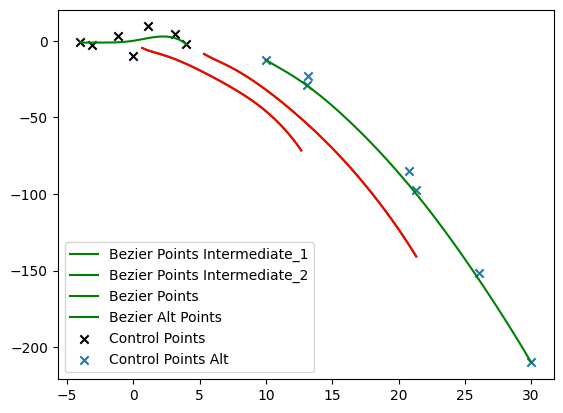

In [35]:
bezier_values, Pi=control_points_2D(xvals,yvals)
bezier_values1, Pi1=control_points_2D(xvalsalt,yvalsalt)
t_fine = np.linspace(0, 1, 40)
#plt.plot(xvals,yvals, label="True Points")
for i in range(2):
    theta=(1+i)/3
    new_B=Pi*theta+Pi1*(1-theta)
    new_points=bezier_values*theta+bezier_values1*(1-theta)
    bezier_points = np.array([bezier_curve2N(6,t, new_B) for t in t_fine])
    plt.plot(bezier_points[:,0],bezier_points[:,1], color='green', label=f"Bezier Points Intermediate_{i+1}")
    plt.plot(new_points[:,0], new_points[:,1],color='red' )
    

plt.plot(bezier_values[:,0],bezier_values[:,1],color='green', label="Bezier Points")
plt.plot(bezier_values1[:,0],bezier_values1[:,1], color='green' ,label="Bezier Alt Points")
plt.scatter([Pi[:,0]],[Pi[:,1]],color='black', marker='x', label="Control Points")
plt.scatter([Pi1[:,0]],[Pi1[:,1]], marker='x', label="Control Points Alt")
plt.legend()

## Bézier Speed Test

In [ ]:
#without access to base-level C code, this isn't as efficient as simply using math library
def EfficientBes(n,t,control_points):
    h=1
    u=1-t
    n1=n+1
    Q=control_points[0]
    for i in range(1,n+1):
        h=h*t*(n1-i)
        h= h/(i*u+h)
        h1=1-h
        Q=h1*Q+h*control_points[i]
    return Q

%timeit EfficientBes(6,0.5,Pi)
%timeit bezier_curve2N(6,0.5,Pi)




11.2 µs ± 102 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)
9.78 µs ± 126 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)
